In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

# SMOTE se elimina del pipeline: se aplica dentro de cada notebook de modelo
# usando ImbPipeline, para garantizar que no contamine los folds de validación cruzada.

print("✅ Librerías listas para el Pipeline.")

✅ Librerías listas para el Pipeline.


In [2]:
# Cargamos el archivo que Iris dejó limpio
# Nos aseguramos de que el nombre coincide con el que hay en data/processed/
df = pd.read_csv("../data/processed/nhanes_clean.csv")

print(f"Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado correctamente: 9074 filas y 24 columnas.


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,status_economico,ui_frecuencia,...,ui_molestia_percibida,ui_impacto_actividades,target_tipo_ui,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,29.0,37.8,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,1,1,none,0,0,0,0,1,1,0
1,21.0,30.2,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,2,1,none,0,0,1,0,0,1,0
2,44.0,39.1,0.0,0.0,0.0,0.0,0.0,0,2.4,4,...,2,2,stress,0,1,0,0,0,1,0
3,33.0,28.9,0.0,0.0,0.0,0.0,0.0,0,1.0,2,...,1,1,none,0,0,0,0,1,1,0
4,68.0,28.1,1.0,1.0,0.0,1.0,0.0,0,3.0,3,...,2,1,urge,0,0,0,1,0,0,1


In [3]:
# Separamos Features (X) y Target (y)
# Las variables leaky se excluyen AQUÍ para que ningún CSV exportado las contenga.
# Cramer V = 1.0 con el target → data leakage garantizado si se incluyen.
cols_leaky = ['ui_esfuerzo_presente', 'ui_urgencia_presente']

X = df.drop(columns=['target_tipo_ui'] + cols_leaky)
y = df['target_tipo_ui']

print(f"Variables leaky excluidas: {cols_leaky}")
print(f"Features restantes: {X.shape[1]}")

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # Garantiza la misma proporción de clases en ambos sets
)

# Comprobación de proporciones
print("\nProporción de clases en el set de ENTRENAMIENTO:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporción de clases en el set de TEST:")
print(y_test.value_counts(normalize=True) * 100)

Variables leaky excluidas: ['ui_esfuerzo_presente', 'ui_urgencia_presente']
Features restantes: 21

Proporción de clases en el set de ENTRENAMIENTO:
target_tipo_ui
none      53.519769
mixed     18.101667
stress    17.481747
urge      10.896818
Name: proportion, dtype: float64

Proporción de clases en el set de TEST:
target_tipo_ui
none      53.553719
mixed     18.071625
stress    17.465565
urge      10.909091
Name: proportion, dtype: float64


## Pipeline de Preprocesamiento (Issue #5)

En esta fase, preparamos los datos para el entrenamiento de modelos de Machine Learning,
asegurando que el proceso sea reproducible y libre de sesgos.

### Exclusión de Variables con Data Leakage
Las variables `ui_esfuerzo_presente` y `ui_urgencia_presente` tienen Cramer V = 1.0 con
el target, lo que significa que definen directamente la clase. Se excluyen en este paso
para que ningún CSV exportado las contenga, evitando que un notebook de modelo pueda
incluirlas accidentalmente.

### División del Dataset (Train/Test Split)
Para evaluar correctamente el rendimiento de nuestros modelos, dividimos los datos en dos conjuntos:
* **Entrenamiento (80%):** Datos con los que los modelos aprenderán los patrones.
* **Prueba (20%):** Datos "ciegos" que utilizaremos para validar la capacidad de predicción real.

> **Decisión Técnica (Estratificación):** Se utiliza el parámetro `stratify=y`. Dado que la
> clase de "urgencia" es minoritaria (aprox. 10.3%), la estratificación garantiza que tanto
> el set de entrenamiento como el de prueba mantengan la misma proporción de casos de UI.

### Ingeniería de Características (Scaling)
Las variables como la `edad` y el `indice_masa_corporal` tienen rangos numéricos muy distintos.
* **Técnica:** Se aplica `StandardScaler` para normalizar los datos.
* **Prevención de Data Leakage:** El escalador se entrena (`fit`) exclusivamente con los datos
  de entrenamiento y solo se aplica (`transform`) al conjunto de prueba.

### SMOTE — se mueve a los notebooks de modelos
SMOTE **no se aplica en este pipeline**. Se aplica dentro de un `ImbPipeline` en cada
notebook de modelo, para que el balanceo ocurra únicamente sobre el fold de entrenamiento
en cada iteración de la validación cruzada. Si se aplicase aquí, muestras sintéticas
generadas con información del fold de validación contaminarían la CV (data leakage).

In [4]:
# 1. Instanciamos el escalador
scaler = StandardScaler()

# 2. ENTRENAMOS y TRANSFORMAMOS el set de entrenamiento
# El escalador "aprende" la media y varianza de X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. SOLO TRANSFORMAMOS el set de test
# Usamos lo aprendido en train para escalar el test (sin mirar sus datos)
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para mantener los nombres de columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("✅ Escalado completado.")
X_train_scaled_df.head()

✅ Escalado completado.


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,status_economico,ui_frecuencia,...,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,0.069578,0.547882,1.295607,2.541738,2.561534,1.357690,1.389872,2.078905,0.908731,2.156357,...,3.034726,2.238423,2.145812,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
1,1.503442,-0.080450,1.295607,-0.393432,-0.390391,1.357690,1.389872,-0.481022,-0.046168,-0.153253,...,-0.329519,-0.000771,-0.656464,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
2,0.815187,-0.059330,1.295607,-0.393432,-0.390391,-0.736545,-0.719491,-0.481022,-0.046168,-0.153253,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,1.738277,-1.738277
3,0.241641,2.554324,1.295607,-0.393432,-0.390391,1.357690,-0.719491,-0.481022,0.908731,2.156357,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282
4,-0.217195,0.772287,1.295607,-0.393432,-0.390391,-0.736545,1.389872,-0.481022,-1.478517,-0.923123,...,-0.329519,-1.120368,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282


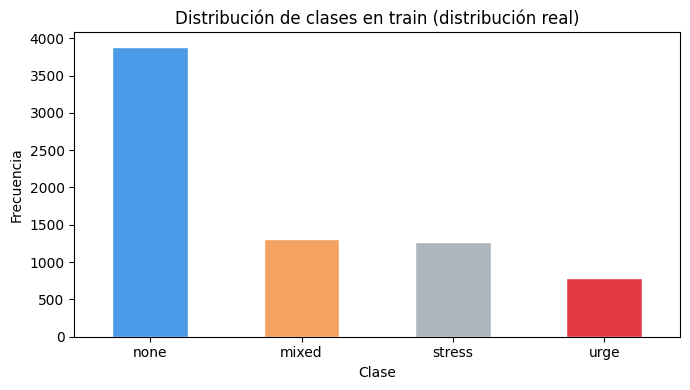


Nota: el balanceo con SMOTE se aplica dentro de cada notebook de modelo,
      dentro del ImbPipeline, fold a fold durante la validación cruzada.


In [5]:
# Visualización de la distribución real de clases (sin balancear)
# Los modelos recibirán estos datos tal cual y aplicarán SMOTE internamente.
fig, ax = plt.subplots(figsize=(7, 4))
y_train.value_counts().plot(kind='bar', ax=ax,
                             title='Distribución de clases en train (distribución real)',
                             color=['#4C9BE8', '#F4A261', '#ADB5BD', '#E63946'],
                             edgecolor='white')
ax.set_xlabel('Clase')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nNota: el balanceo con SMOTE se aplica dentro de cada notebook de modelo,")
print("      dentro del ImbPipeline, fold a fold durante la validación cruzada.")

In [6]:
# Verificación de la integridad de los datos finales
columna_prueba = X_train_scaled_df.columns[0]

verificacion = pd.DataFrame({
    'Set': ['X_train_scaled', 'X_test_scaled'],
    'Registros': [X_train_scaled.shape[0], X_test_scaled.shape[0]],
    'Features':  [X_train_scaled.shape[1], X_test_scaled.shape[1]],
    'Nulos': [X_train_scaled_df.isnull().sum().sum(), X_test_scaled_df.isnull().sum().sum()],
    'Media_col_escalada': [
        X_train_scaled_df[columna_prueba].mean().round(4),
        X_test_scaled_df[columna_prueba].mean().round(4)
    ]
})

print(f"📊 RESUMEN DE CALIDAD (Columna analizada: {columna_prueba})")
display(verificacion)

# Confirmar que las leaky vars no están en ningún set
for col in ['ui_esfuerzo_presente', 'ui_urgencia_presente']:
    assert col not in X_train_scaled_df.columns, f"⚠️ {col} sigue presente en train!"
    assert col not in X_test_scaled_df.columns,  f"⚠️ {col} sigue presente en test!"
print("✅ Verificación leaky vars: ninguna presente en los datasets exportados.")

📊 RESUMEN DE CALIDAD (Columna analizada: edad_anios)


,Set,Registros,Features,Nulos,Media_col_escalada
0,X_train_scaled,7259,21,0,0.0000
1,X_test_scaled,1815,21,0,0.0136


✅ Verificación leaky vars: ninguna presente en los datasets exportados.


## Consolidación de Datasets en Memoria

Los datasets exportados por este pipeline contienen:

* **X_train_scaled / y_train:** Características escaladas con distribución real (sin SMOTE).
  Los notebooks de modelos aplicarán SMOTE internamente dentro de su `ImbPipeline`.
* **X_test_scaled / y_test:** Datos de validación escalados con los parámetros de entrenamiento.
  Representan la distribución real de producción y nunca son balanceados.
* **cv_config.pkl:** Configuración de `StratifiedKFold` compartida por todos los modelos,
  garantizando que todos usen exactamente el mismo esquema de validación cruzada.
* **scaler.pkl:** Objeto `StandardScaler` entrenado, necesario para escalar nuevas
  observaciones en producción.

In [7]:
X_train_scaled_df.isnull().sum().sum()

np.int64(0)

In [8]:
# 1. Rutas
path_models = "../models/"
path_data_processed = "../data/processed/"

# Creamos las carpetas si no existen
os.makedirs(path_models, exist_ok=True)
os.makedirs(path_data_processed, exist_ok=True)

# 2. Guardado del scaler en el directorio 'models' con extensión .pkl
joblib.dump(scaler, os.path.join(path_models, 'pipeline.pkl'))
print(f"✅ Scaler guardado en: {os.path.join(path_models, 'pipeline.pkl')}")

# 3. Configuración de CV compartida — todos los modelos cargan este objeto para garantizar exactamente el mismo esquema de validación cruzada.
cv_config = {
    'n_splits':    5,
    'shuffle':     True,
    'random_state': 42
}
joblib.dump(cv_config, os.path.join(path_models, 'cv_config.pkl'))
print(f"✅ cv_config guardado en: {os.path.join(path_models, 'cv_config.pkl')}")

# 4. Datasets escalados SIN SMOTE
#    Nombre actualizado: X_train_scaled / X_test_scaled (sin '_final')
#    para reflejar que SMOTE ya no se aplica aquí.
X_train_scaled_df.to_csv(os.path.join(path_data_processed, 'X_train_scaled.csv'), index=False)
y_train.to_csv(os.path.join(path_data_processed, 'y_train.csv'), index=False)
X_test_scaled_df.to_csv(os.path.join(path_data_processed, 'X_test_scaled.csv'), index=False)
y_test.to_csv(os.path.join(path_data_processed, 'y_test.csv'), index=False)

print(f"\n✅ Datasets exportados a: {path_data_processed}")
print("   - X_train_scaled.csv  (escalado, sin SMOTE, sin leaky vars)")
print("   - y_train.csv         (distribución real)")
print("   - X_test_scaled.csv   (escalado, sin SMOTE, sin leaky vars)")
print("   - y_test.csv          (distribución real)")

✅ Scaler guardado en: ../models/pipeline.pkl
✅ cv_config guardado en: ../models/cv_config.pkl

✅ Datasets exportados a: ../data/processed/
   - X_train_scaled.csv  (escalado, sin SMOTE, sin leaky vars)
   - y_train.csv         (distribución real)
   - X_test_scaled.csv   (escalado, sin SMOTE, sin leaky vars)
   - y_test.csv          (distribución real)


## 💾 Persistencia y Exportación del Pipeline

El pipeline exporta los siguientes artefactos:

| Artefacto | Ruta | Descripción |
|-----------|------|-------------|
| `pipeline.pkl` | `models/` | `StandardScaler` entrenado con X_train. Necesario para escalar nuevas observaciones en producción. |
| `cv_config.pkl` | `models/` | `dict` con la configuración de `StratifiedKFold` compartida por todos los modelos. |
| `X_train_scaled.csv` | `data/processed/` | Features de entrenamiento escaladas. **Sin SMOTE, sin leaky vars.** |
| `y_train.csv` | `data/processed/` | Target de entrenamiento con distribución real. |
| `X_test_scaled.csv` | `data/processed/` | Features de test escaladas. **Sin SMOTE, sin leaky vars.** |
| `y_test.csv` | `data/processed/` | Target de test con distribución real. |

### Cómo usar estos artefactos en los notebooks de modelos

```python
import joblib, pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

cv_config = joblib.load('../models/cv_config.pkl')
skf = StratifiedKFold(**cv_config)  # mismo esquema en todos los modelos

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE solo sobre el fold de train
    ('model', TuModelo(...))
])
```

Con este diseño, SMOTE se aplica **fold a fold** dentro de la CV, garantizando que
ninguna muestra sintética del fold de validación contamine el entrenamiento.

Con este paso, el **Pipeline de Preprocesamiento** queda oficialmente cerrado y listo para su integración.